<a href="https://colab.research.google.com/github/MuhammadRabees/AI-ML-Internship-DevelopersHub/blob/main/Task2_Stock_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement
Stock markets generate massive historical data every day. Investors often want to estimate the next day's closing price using past trends. The challenge is to build a machine learning model that can learn patterns from historical stock data and make accurate short-term predictions.

# Goal
The goal of this project is to:

* Retrieve historical stock data

* Use selected features (Open, High, Low, Volume)

* Train a machine learning model

* Predict the next day closing price

* Compare predicted vs actual values


In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Step 1: Load Stock Data

In [17]:
ticker = "AAPL"   # Example: Apple stock

data = yf.download(ticker, start="2020-01-01", end="2024-12-31")

data.head()

/tmp/ipython-input-1606833957.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200


#Step 2: Feature Selection + Target Creation



In [18]:
# --- Create Target (Next Day Close) ---
data["Target"] = data["Close"].shift(-1)

data["Prev_Close"] = data["Close"].shift(1)

# --- Remove missing values ---
data.dropna(inplace=True)

# --- Feature Selection ---
features = ["Open", "High", "Low", "Volume", "Prev_Close"]

X = data[features]
y = data["Target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1255, 5)
Target shape: (1255,)


#Step 3: Split dataset into training and testing sets

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

#Step 4: Train Model (Random Forest)

In [20]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

# Step 5: Make Prediction

In [21]:
rf_pred = rf_model.predict(X_test)

# Step 6: Evaluation

In [22]:
def evaluate(true, pred, name):
    print(name)
    print("MAE:", mean_absolute_error(true, pred))
    print("RMSE:", np.sqrt(mean_squared_error(true, pred)))
    print("--------------------")
evaluate(y_test, rf_pred, "Random Forest")

Random Forest
MAE: 19.022826854204283
RMSE: 25.69498829636212
--------------------


#Step 7: Plot Actual vs Predicted closing price

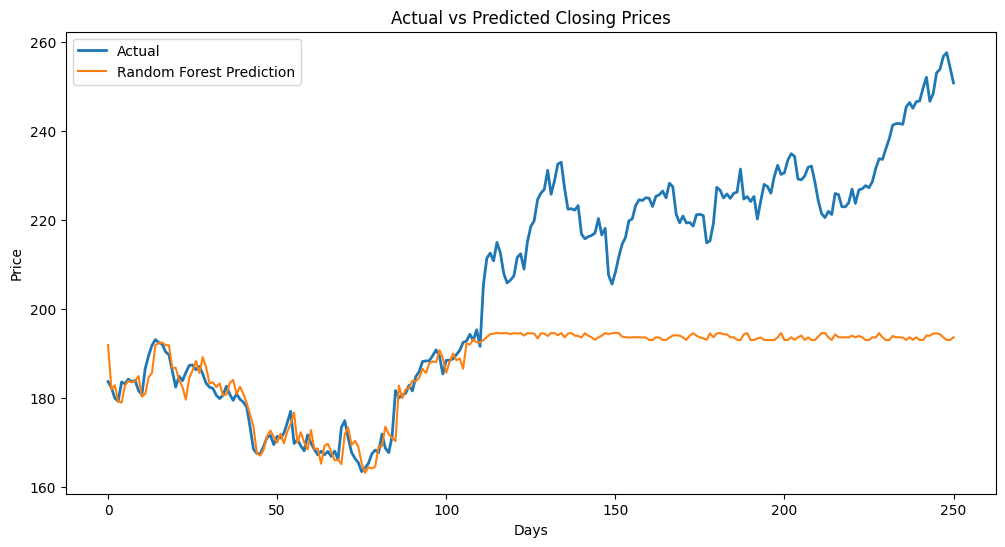

In [23]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(rf_pred, label="Random Forest Prediction")

plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()

#Step 8: Predict Next Day Closing Price

In [16]:
latest_data = data[features].iloc[-1].values.reshape(1,-1)

rf_next = rf_model.predict(latest_data)
print("Next Day Prediction (Random Forest):", rf_next[0])

Next Day Prediction (Random Forest): 193.70898513793946
